In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
from imblearn.under_sampling import NearMiss
import warnings
warnings.filterwarnings('ignore')

sns.set(style='whitegrid')
%matplotlib inline

## Cargar datos

In [4]:
df = pd.read_csv('creditcard.csv')
print(df.shape)
print(df['Class'].value_counts(normalize=True))
df.head()

(284807, 31)
Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## Distribución de target

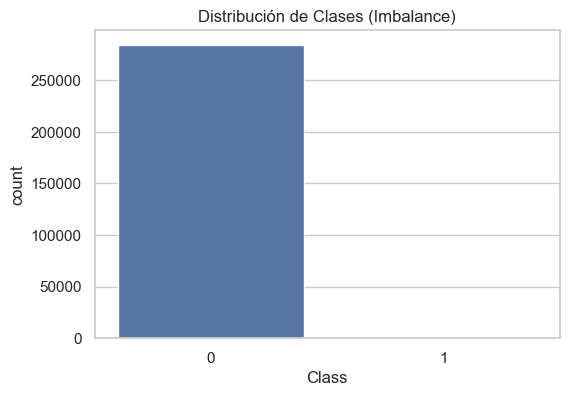

Fraudes: 492 (0.17%)


In [5]:
plt.figure(figsize=(6,4))
sns.countplot(x='Class', data=df)
plt.title('Distribución de Clases (Imbalance)')
plt.show()

print(f"Fraudes: {df['Class'].sum()} ({df['Class'].mean()*100:.2f}%)")

## EDA

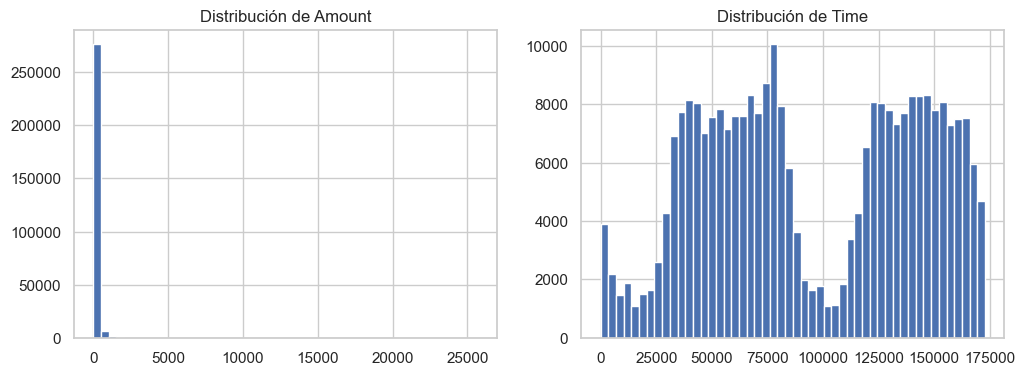

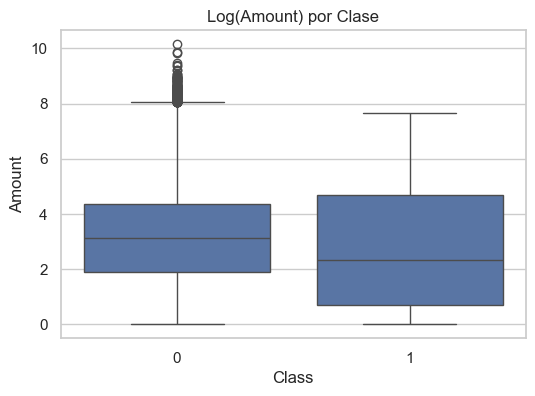

In [6]:
fig, axes = plt.subplots(1,2, figsize=(12,4))
df['Amount'].hist(bins=50, ax=axes[0])
axes[0].set_title('Distribución de Amount')
df['Time'].hist(bins=50, ax=axes[1])
axes[1].set_title('Distribución de Time')
plt.show()

df_log = np.log(df['Amount']+1)
plt.figure(figsize=(6,4))
sns.boxplot(x='Class', y=df_log, data=df)
plt.title('Log(Amount) por Clase')
plt.show()

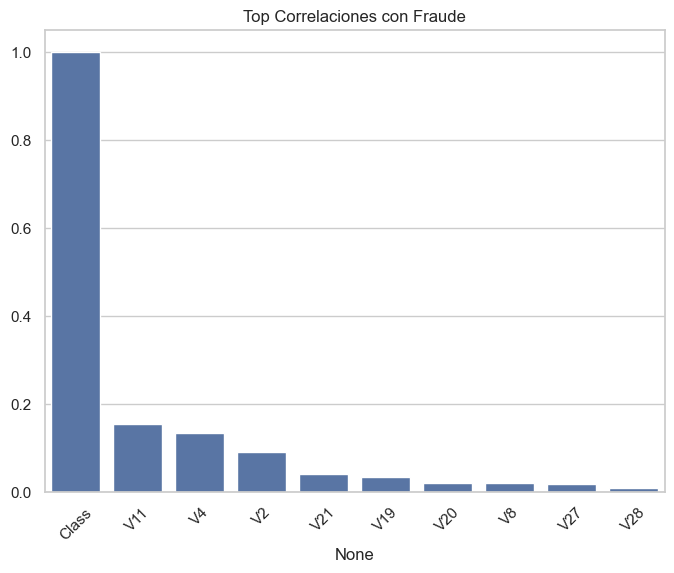

In [7]:
corr = df.corr()['Class'].sort_values(ascending=False).head(10)
plt.figure(figsize=(8,6))
sns.barplot(x=corr.index, y=corr.values)
plt.title('Top Correlaciones con Fraude')
plt.xticks(rotation=45)
plt.show()

## Preprocesamiento

In [8]:
# Features y target
X = df.drop('Class', axis=1)
y = df['Class']

# Escala Amount y Time
scaler = StandardScaler()
X['Amount_scaled'] = scaler.fit_transform(X[['Amount']])
X['Time_scaled'] = scaler.fit_transform(X[['Time']])
X = X.drop(['Time', 'Amount'], axis=1)

print(X.shape)

(284807, 30)


In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

nm = NearMiss()
X_train_res, y_train_res = nm.fit_resample(X_train, y_train)
print(f"Train original: {y_train.value_counts()}")
print(f"Train resampled: {pd.Series(y_train_res).value_counts()}")

Train original: Class
0    227451
1       394
Name: count, dtype: int64
Train resampled: Class
0    394
1    394
Name: count, dtype: int64


## Modelos

### Regresión logística (Supervisado)

In [10]:
lr = LogisticRegression(random_state=42)
lr.fit(X_train_res, y_train_res)

y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:,1]

print("ROC-AUC:", roc_auc_score(y_test, y_prob_lr))
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr))

ROC-AUC: 0.9239859263204437

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.61      0.76     56864
           1       0.00      0.96      0.01        98

    accuracy                           0.61     56962
   macro avg       0.50      0.78      0.38     56962
weighted avg       1.00      0.61      0.76     56962



### Matriz de confusión

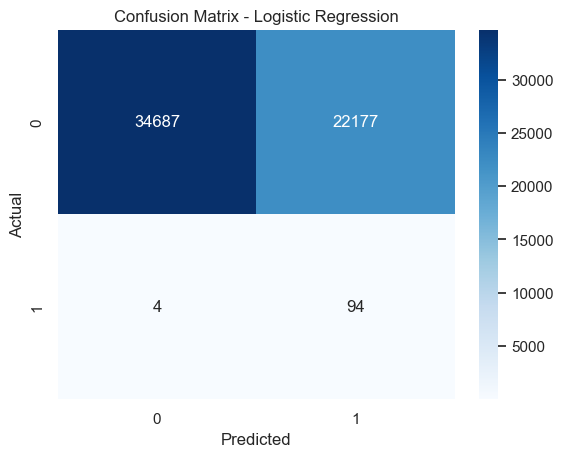

In [11]:
cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Logistic Regression')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

### Isolation forest (No supervisado)

In [12]:
iso = IsolationForest(contamination=0.0017, random_state=42)
iso.fit(X_train) 

y_pred_iso = iso.predict(X_test)
y_pred_iso = np.where(y_pred_iso == -1, 1, 0) 

print("ROC-AUC (proxy):", roc_auc_score(y_test, 1 - iso.decision_function(X_test)))
print("\nClassification Report:\n", classification_report(y_test, y_pred_iso))

ROC-AUC (proxy): 0.9536498828569131

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.31      0.33      0.32        98

    accuracy                           1.00     56962
   macro avg       0.65      0.66      0.66     56962
weighted avg       1.00      1.00      1.00     56962



### Matriz de confusión

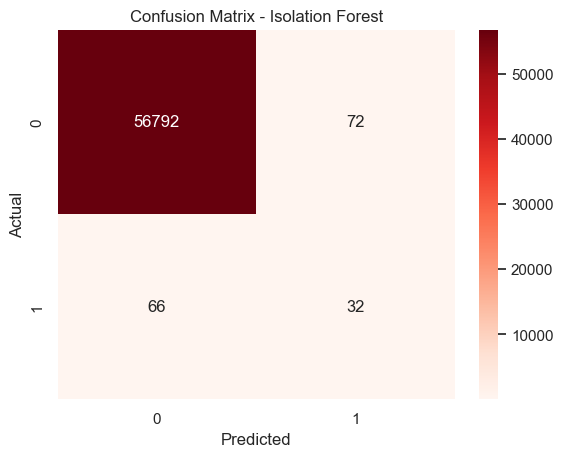

In [13]:
cm_iso = confusion_matrix(y_test, y_pred_iso)
sns.heatmap(cm_iso, annot=True, fmt='d', cmap='Reds')
plt.title('Confusion Matrix - Isolation Forest')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

## Comparación de modelos

                Modelo  ROC-AUC  Precision (Clase 1)  Recall (Clase 1)  \
0  Logistic Regression    0.924                0.004             0.959   
1     Isolation Forest    0.954                0.308             0.327   

   F1-Score (Clase 1)  
0               0.008  
1               0.317  


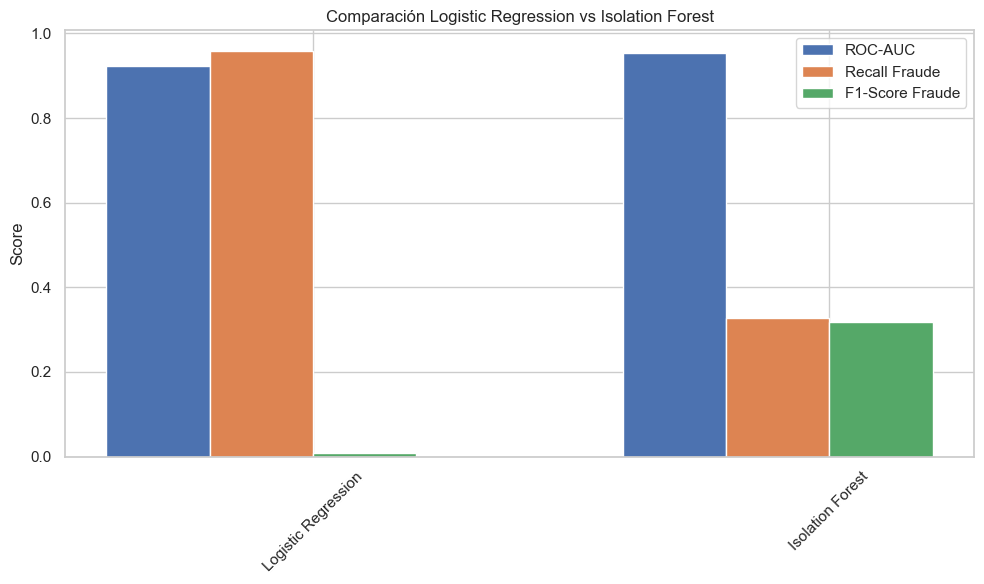

In [14]:
metrics = {
    'Modelo': ['Logistic Regression', 'Isolation Forest'],
    'ROC-AUC': [roc_auc_score(y_test, y_prob_lr), roc_auc_score(y_test, 1 - iso.decision_function(X_test))],
    'Precision (Clase 1)': [classification_report(y_test, y_pred_lr, output_dict=True)['1']['precision'],
                           classification_report(y_test, y_pred_iso, output_dict=True)['1']['precision']],
    'Recall (Clase 1)': [classification_report(y_test, y_pred_lr, output_dict=True)['1']['recall'],
                         classification_report(y_test, y_pred_iso, output_dict=True)['1']['recall']],
    'F1-Score (Clase 1)': [classification_report(y_test, y_pred_lr, output_dict=True)['1']['f1-score'],
                           classification_report(y_test, y_pred_iso, output_dict=True)['1']['f1-score']]
}

df_metrics = pd.DataFrame(metrics)
print(df_metrics.round(3))

# Gráfico comparativo
fig, ax = plt.subplots(figsize=(10,6))
x = np.arange(len(metrics['Modelo']))
width = 0.2

ax.bar(x - 1.5*width, df_metrics['ROC-AUC'], width, label='ROC-AUC')
ax.bar(x - 0.5*width, df_metrics['Recall (Clase 1)'], width, label='Recall Fraude')
ax.bar(x + 0.5*width, df_metrics['F1-Score (Clase 1)'], width, label='F1-Score Fraude')

ax.set_ylabel('Score')
ax.set_title('Comparación Logistic Regression vs Isolation Forest')
ax.set_xticks(x)
ax.set_xticklabels(metrics['Modelo'])
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()